# PTB-XL — Exploration interactive des ECG

Notebook d'exploration du dataset **PTB-XL** (PhysioNet 1.0.1) : ~21 799 ECG 12 dérivations,
10 s, disponibles en **100 Hz** (`records100`, suffixe `_lr`) et **500 Hz** (`records500`, `_hr`).

Objectif de ce notebook : **comprendre et visualiser les données** avant de concevoir le JEPA.
Aucune décision de modélisation ici (pas de masquage, pas d'architecture) — que de l'exploration.

Sommaire :
1. Configuration & chargement des métadonnées
2. Vue d'ensemble du dataset (classes, démographie, qualité, folds)
3. Chargement d'un enregistrement (100 & 500 Hz)
4. **Explorateur interactif** — une dérivation, 100 vs 500 Hz comparés
5. **Grille 12 dérivations interactive**

## 1. Configuration & chargement des métadonnées

In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import wfdb

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

# Racine du dataset (relatif à ce notebook, placé à la racine du projet "Cardiac JEPA")
DATA_DIR = Path("ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1")
assert (DATA_DIR / "ptbxl_database.csv").exists(), f"Dataset introuvable dans {DATA_DIR.resolve()}"

LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
FS_LR, FS_HR = 100, 500
DURATION_S = 10.0
print("Dataset :", DATA_DIR.resolve())

Dataset : /Users/julesvidegrain/Desktop/Cardiac JEPA/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1


In [2]:
# Métadonnées cliniques
df = pd.read_csv(DATA_DIR / "ptbxl_database.csv", index_col="ecg_id")
df.scp_codes = df.scp_codes.apply(ast.literal_eval)  # str -> dict {code: likelihood}

# Table d'agrégation SCP -> superclasse diagnostique
scp = pd.read_csv(DATA_DIR / "scp_statements.csv", index_col=0)
scp_diag = scp[scp.diagnostic == 1]

def to_superclass(scp_dict):
    return sorted({scp_diag.loc[k].diagnostic_class
                   for k in scp_dict if k in scp_diag.index})

df["superclass"] = df.scp_codes.apply(to_superclass)
df["sex_label"] = df.sex.map({0: "M", 1: "F"})

print(f"{len(df)} enregistrements | patients uniques : {df.patient_id.nunique()}")
print("Superclasses diagnostiques :", sorted(scp_diag.diagnostic_class.unique()))
df[["patient_id", "age", "sex_label", "report", "scp_codes", "superclass", "strat_fold"]].head()

21837 enregistrements | patients uniques : 18885
Superclasses diagnostiques : ['CD', 'HYP', 'MI', 'NORM', 'STTC']


,patient_id,age,sex_label,report,scp_codes,superclass,strat_fold
ecg_id,,,,,,,
1,15709.0,56.0,F,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM],3
2,13243.0,19.0,M,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM],2
3,20372.0,37.0,F,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",[NORM],5
4,17014.0,24.0,M,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",[NORM],3
5,17448.0,19.0,F,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",[NORM],4


## 2. Vue d'ensemble du dataset

Les 5 **superclasses** PTB-XL : `NORM` (normal), `MI` (infarctus), `STTC` (anomalies ST/T),
`CD` (troubles de conduction), `HYP` (hypertrophie). Un ECG peut être **multi-label**
(plusieurs superclasses) ou vide (aucun code diagnostique).

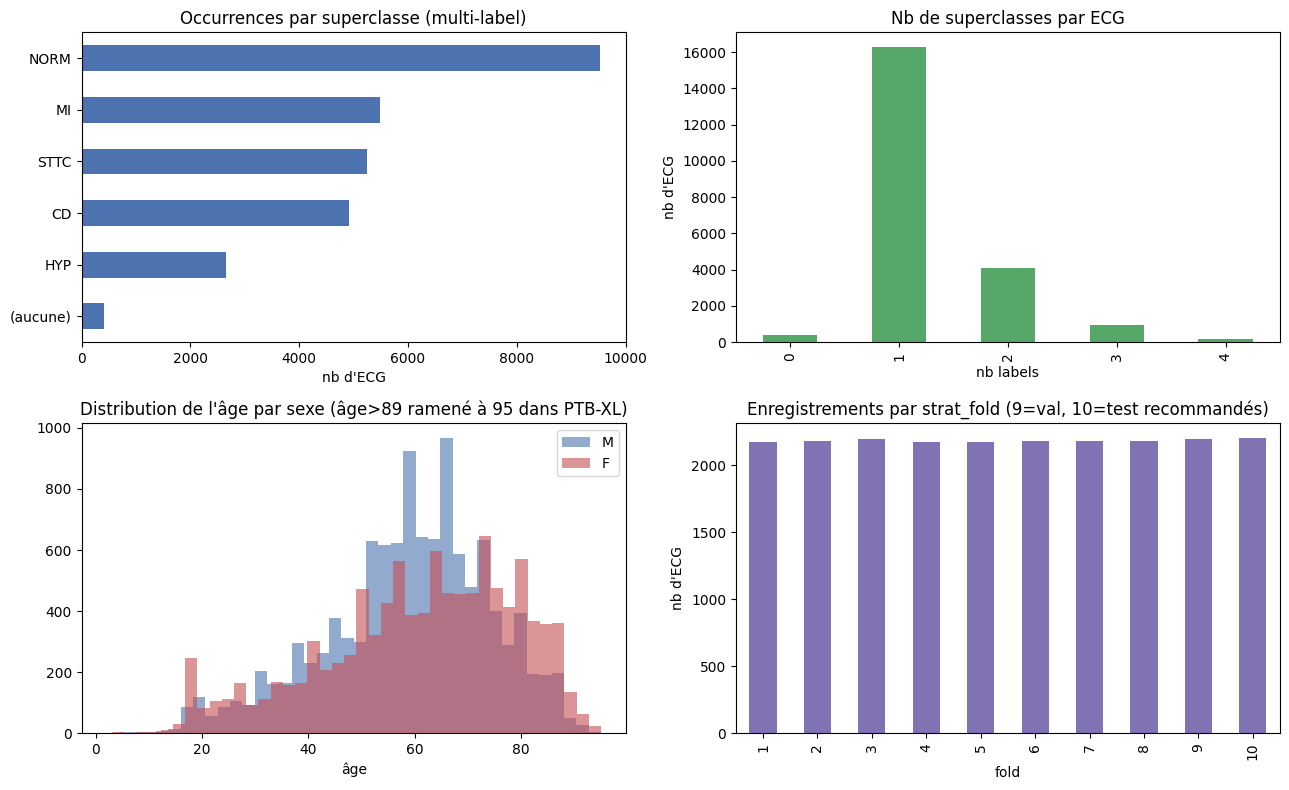

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (a) Distribution des superclasses (multi-label -> on compte les occurrences)
super_counts = pd.Series(
    [c for cs in df.superclass for c in cs]
).value_counts()
n_empty = (df.superclass.str.len() == 0).sum()
super_counts["(aucune)"] = n_empty
super_counts.sort_values().plot.barh(ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Occurrences par superclasse (multi-label)")
axes[0, 0].set_xlabel("nb d'ECG")

# (b) Nb de superclasses par ECG
df.superclass.str.len().value_counts().sort_index().plot.bar(ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Nb de superclasses par ECG")
axes[0, 1].set_xlabel("nb labels"); axes[0, 1].set_ylabel("nb d'ECG")

# (c) Âge par sexe
for s, col in [("M", "#4C72B0"), ("F", "#C44E52")]:
    axes[1, 0].hist(df[df.sex_label == s].age.clip(upper=95), bins=40, alpha=0.6, label=s, color=col)
axes[1, 0].set_title("Distribution de l'âge par sexe (âge>89 ramené à 95 dans PTB-XL)")
axes[1, 0].set_xlabel("âge"); axes[1, 0].legend()

# (d) Répartition par strat_fold (splits officiels ; fold 10 = test)
df.strat_fold.value_counts().sort_index().plot.bar(ax=axes[1, 1], color="#8172B3")
axes[1, 1].set_title("Enregistrements par strat_fold (9=val, 10=test recommandés)")
axes[1, 1].set_xlabel("fold"); axes[1, 1].set_ylabel("nb d'ECG")

plt.tight_layout(); plt.show()

In [4]:
# Annotations de qualité du signal (utile pour le JEPA : bruit, dérive, pacemaker...)
quality_cols = ["baseline_drift", "static_noise", "burst_noise",
                "electrodes_problems", "extra_beats", "pacemaker"]
qual = pd.DataFrame({
    "ECG annotés (non vide)": [df[c].notna().sum() for c in quality_cols]
}, index=quality_cols)
qual["% du dataset"] = (100 * qual.iloc[:, 0] / len(df)).round(1)
print("Signaux validés par un humain :", int(df.validated_by_human.sum()),
      f"({100*df.validated_by_human.mean():.0f}%)")
qual

Signaux validés par un humain : 16094 (74%)


,ECG annotés (non vide),% du dataset
baseline_drift,1607,7.4
static_noise,3262,14.9
burst_noise,613,2.8
electrodes_problems,30,0.1
extra_beats,1954,8.9
pacemaker,293,1.3


## 3. Chargement d'un enregistrement

`wfdb.rdsamp` lit un couple `.dat`/`.hea` et renvoie `(signal[n_samples, 12], meta)`.
On charge à la demande (le dataset complet ne tient pas en RAM confortablement).

In [5]:
# Charge un ECG. fs=100 -> records100 (_lr), fs=500 -> records500 (_hr).
# Renvoie (signal [n, 12] en mV, temps [n] en s).
def load_ecg(ecg_id, fs=100):
    row = df.loc[ecg_id]
    rel = row.filename_lr if fs == 100 else row.filename_hr
    sig, meta = wfdb.rdsamp(str(DATA_DIR / rel))
    t = np.arange(sig.shape[0]) / meta["fs"]
    return sig, t

def ecg_summary(ecg_id):
    r = df.loc[ecg_id]
    codes = ", ".join(f"{k}:{v:g}" for k, v in r.scp_codes.items()) or "—"
    flags = [c for c in quality_cols if pd.notna(r[c])]
    return (f"ecg_id={ecg_id} | patient={int(r.patient_id)} | {r.sex_label} {r.age:g} ans "
            f"| fold={r.strat_fold}\n"
            f"superclasse : {r.superclass or '(aucune)'}\n"
            f"SCP codes   : {codes}\n"
            f"rapport     : {r.report}\n"
            f"qualité     : {', '.join(flags) if flags else 'RAS'}")

# Test
s100, t100 = load_ecg(1, 100)
s500, t500 = load_ecg(1, 500)
print(f"100 Hz : {s100.shape}   500 Hz : {s500.shape}")
print(ecg_summary(1))

100 Hz : (1000, 12)   500 Hz : (5000, 12)
ecg_id=1 | patient=15709 | F 56 ans | fold=3
superclasse : ['NORM']
SCP codes   : NORM:100, LVOLT:0, SR:0
rapport     : sinusrhythmus periphere niederspannung
qualité     : static_noise


## 4. Explorateur interactif — 100 Hz vs 500 Hz

Choisis une superclasse (filtre), tire un ECG au hasard ou saisis un `ecg_id`, et une dérivation.
Les deux résolutions sont superposées puis affichées l'une au-dessus de l'autre pour comparer
le compromis détail/coût avant de trancher pour le JEPA.

In [6]:
w_super = widgets.Dropdown(
    options=["ALL", "NORM", "MI", "STTC", "CD", "HYP"], value="ALL", description="Superclasse")
w_ecg = widgets.BoundedIntText(value=1, min=int(df.index.min()), max=int(df.index.max()),
                               description="ecg_id")
w_lead = widgets.Dropdown(options=LEADS, value="II", description="Dérivation")
btn_rand = widgets.Button(description="Aléatoire ↻", button_style="info")
out = widgets.Output()

def _subset_ids(super_name):
    if super_name == "ALL":
        return df.index
    return df.index[df.superclass.apply(lambda cs: super_name in cs)]

def _render(*_):
    with out:
        out.clear_output(wait=True)
        ecg_id = int(w_ecg.value)
        if ecg_id not in df.index:
            print("ecg_id inexistant"); return
        li = LEADS.index(w_lead.value)
        s100, t100 = load_ecg(ecg_id, 100)
        s500, t500 = load_ecg(ecg_id, 500)
        print(ecg_summary(ecg_id))
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                            subplot_titles=(f"{w_lead.value} — 100 Hz",
                                            f"{w_lead.value} — 500 Hz"))
        fig.add_trace(go.Scatter(x=t100, y=s100[:, li], line=dict(width=1, color="#4C72B0"),
                                 name="100 Hz"), row=1, col=1)
        fig.add_trace(go.Scatter(x=t500, y=s500[:, li], line=dict(width=1, color="#C44E52"),
                                 name="500 Hz"), row=2, col=1)
        fig.update_xaxes(title_text="temps (s)", row=2, col=1)
        fig.update_yaxes(title_text="mV"); fig.update_layout(
            height=520, showlegend=False, margin=dict(l=60, r=20, t=40, b=40))
        fig.show()

def _on_random(_):
    ids = _subset_ids(w_super.value)
    if len(ids): w_ecg.value = int(np.random.choice(ids))
    else: _render()

btn_rand.on_click(_on_random)
for w in (w_ecg, w_lead): w.observe(_render, names="value")
w_super.observe(lambda c: _on_random(None), names="value")

display(widgets.HBox([w_super, w_ecg, w_lead, btn_rand]), out)
_render()

Output()

## 5. Grille 12 dérivations

Vue clinique standard : les 12 dérivations d'un même ECG, à la résolution choisie.

In [ ]:
w_ecg2 = widgets.BoundedIntText(value=1, min=int(df.index.min()), max=int(df.index.max()),
                                description="ecg_id")
w_fs = widgets.ToggleButtons(options=[("100 Hz", 100), ("500 Hz", 500)], value=100,
                             description="Résolution")
btn_rand2 = widgets.Button(description="Aléatoire ↻", button_style="info")
out2 = widgets.Output()

def _render_grid(*_):
    with out2:
        out2.clear_output(wait=True)
        ecg_id = int(w_ecg2.value)
        if ecg_id not in df.index:
            print("ecg_id inexistant"); return
        sig, t = load_ecg(ecg_id, w_fs.value)
        print(ecg_summary(ecg_id))
        fig = make_subplots(rows=6, cols=2, shared_xaxes=True,
                            vertical_spacing=0.03, horizontal_spacing=0.06,
                            subplot_titles=LEADS)
        for i in range(12):
            r, c = i % 6 + 1, i // 6 + 1
            fig.add_trace(go.Scatter(x=t, y=sig[:, i], line=dict(width=0.8, color="#333")),
                          row=r, col=c)
        fig.update_layout(height=900, showlegend=False,
                          margin=dict(l=40, r=20, t=30, b=30))
        fig.show()

btn_rand2.on_click(lambda _: setattr(w_ecg2, "value", int(np.random.choice(df.index))))
for w in (w_ecg2, w_fs): w.observe(_render_grid, names="value")

display(widgets.HBox([w_ecg2, w_fs, btn_rand2]), out2)
_render_grid()

Output()